# Demo 2 — Identifying new lizards, including ones never seen

[Demo 1](demo-1-training.ipynb) trained a model on 12 lizards. This notebook runs
the batch in `data/new/lizard_demo-pattern/` — **20 new photographs** — against
that gallery.

Thirteen show animals already in the gallery. **Seven show four animals the model
has never seen.** A closed-set system must assign each of those seven to *some*
known individual and will be wrong every time. ReMatch is allowed to answer
*new individual* — that is the point of the method, and this notebook is where
you can check whether it actually does.

In the real monitoring workflow this is what happens after a field session: a
batch of new captures arrives, ReMatch ranks candidates for each, and an expert
confirms them before anything enters the database. This mirrors `scripts/Q2`–`Q4`.
Run [Demo 1](demo-1-training.ipynb) first.

## Setup

In [1]:
import os
os.environ["NEW_IMAGES_NAME"] = "lizard_demo"   # must be set before params is imported

import os, sys, json
from pathlib import Path

import cv2, numpy as np, pandas as pd, torch, joblib
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))          # run from the repository root

import params.params as params
import utils.demo_utils as D

# SuperPoint pads to a fixed keypoint count with random points, so an unseeded
# run picks a different classifier and a different threshold every time.
D.set_seed(0)

# CLAHE contrast enhancement, applied to every image before its wireframe is
# extracted. On by default: this is what `scripts/` does and what the published
# results were produced with. Set it to False to see what it buys you on your
# own photographs. Keep demo-1 and demo-2 on the same setting - the model is
# trained on whatever this produces.
D.ENHANCE_CONTRAST = True

# 20 queries against 48 gallery images is 960 matches, about twelve minutes on a
# CPU. False loads the table bundled in data/precomputed/ instead - made by the
# same code (scripts/make_demo_matches.py). True recomputes it here.
RUN_MATCHING = False
PRECOMPUTED  = Path("data/precomputed/lizard_demo_query_matches.parquet")

DEVICE    = D.device()
PATTERN   = Path(params.PATTERN_IMAGES_FOLDER)          # data/images-pattern
QUERY     = Path(params.NEW_PATTERN_IMAGES_FOLDER)      # data/new/lizard_demo-pattern

truth = json.load(open(Path("data") / "lizard_demo_ground_truth.json"))
individuals = truth["gallery_individuals"]

need = [params.SCALER_PATH, params.BEST_MODEL_PATH, params.LOGREG_MODEL_PATH,
        params.BEST_THRESHOLD_PATH]
missing = [f for f in need if not os.path.exists(f)]
if missing:
    raise SystemExit("No trained model — run demo-1-training.ipynb first.\nMissing: "
                     + ", ".join(missing))

scaler = joblib.load(params.SCALER_PATH)
clf    = joblib.load(params.BEST_MODEL_PATH)
meta   = joblib.load(params.LOGREG_MODEL_PATH)
TAU    = float(open(params.BEST_THRESHOLD_PATH).read().strip())

print("batch      :", params.NEW_IMAGES_NAME)
print("device     :", DEVICE)
print("pair model :", type(clf).__name__)
print("meta model :", type(meta).__name__)
print("tau*       :", TAU)
print("gallery    :", len(individuals), "individuals")

batch      : lizard_demo
device     : cpu
pair model : RandomForestClassifier
meta model : LogisticRegression
tau*       : 0.04
gallery    : 12 individuals


## The query batch

In a real deployment you would not know these answers — they come from the
dataset's own expert annotations, and are used only to score the result at the
end.

20 query images: 13 of individuals in the gallery, 7 of individuals that are not

in_gallery  true_identity
False       lizard_C307      2
            lizard_C328      2
            lizard_C563      2
            lizard_C564      1
True        lizard_C116      1
            lizard_C185      2
            lizard_C214      2
            lizard_C309      1
            lizard_C373      2
            lizard_C421      1
            lizard_C501      2
            lizard_C56       1
            lizard_C84       1


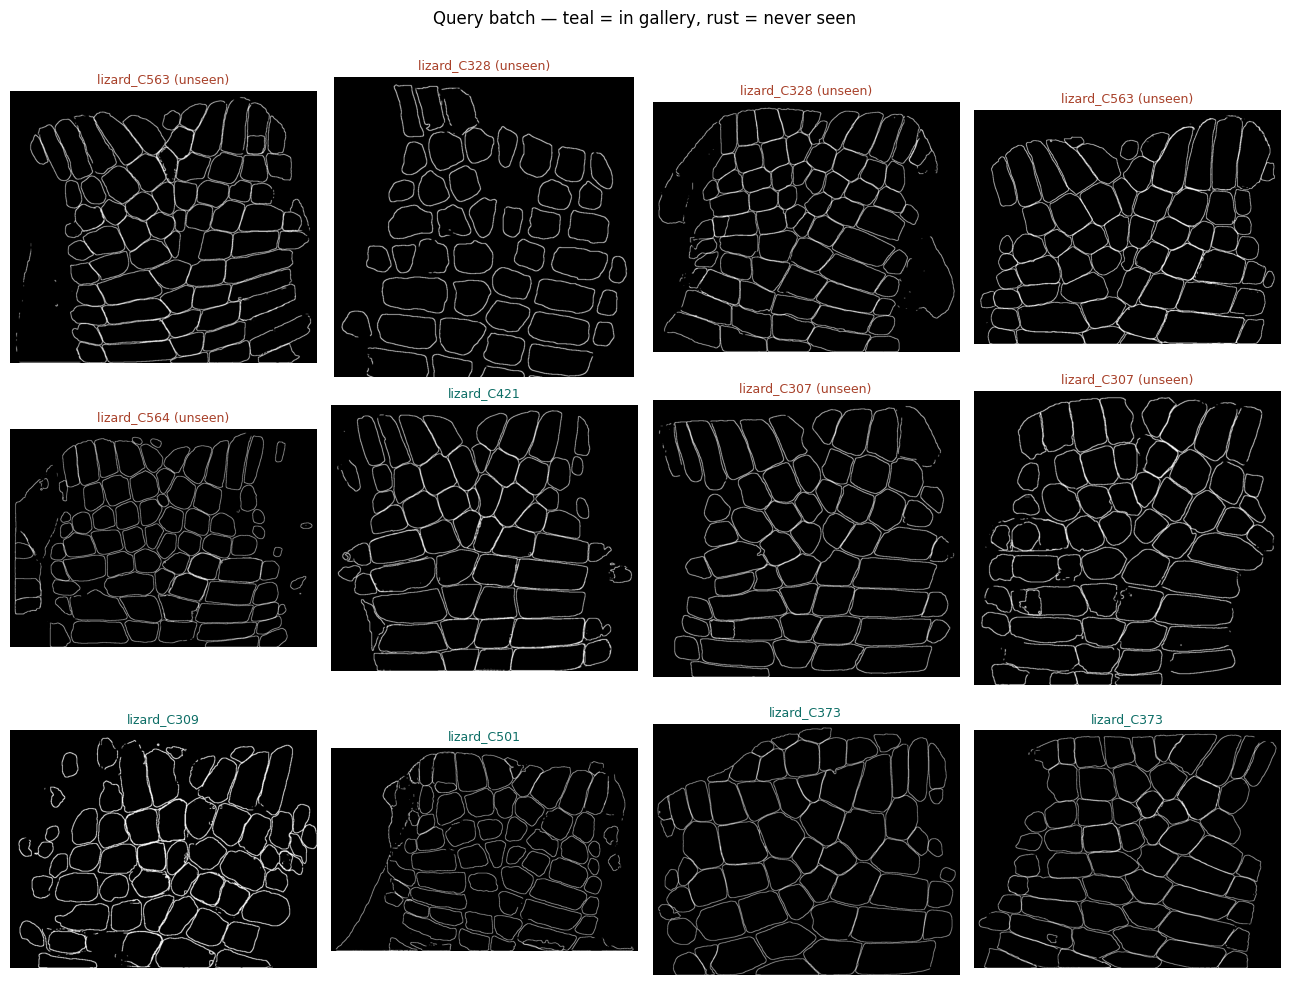

In [2]:
qdf = pd.DataFrame(truth["query"])
print(f"{len(qdf)} query images: {qdf['in_gallery'].sum()} of individuals in the gallery, "
      f"{(~qdf['in_gallery']).sum()} of individuals that are not\n")
print(qdf.groupby(["in_gallery", "true_identity"]).size().to_string())

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax, row in zip(axes.ravel(), list(qdf.itertuples())[:12]):
    ax.imshow(D.load_gray(QUERY / row.image), cmap="gray")
    ax.set_title(row.true_identity if row.in_gallery else f"{row.true_identity} (unseen)",
                 fontsize=9, color="#0d6e66" if row.in_gallery else "#a8412a")
    ax.axis("off")
plt.suptitle("Query batch — teal = in gallery, rust = never seen", y=1.005)
plt.tight_layout(); plt.show()

## Step 1 — Match every query against the whole gallery

20 queries against 48 gallery images is 960 matches. Note the asymmetry with
training: the gallery's wireframes were already computed, so only the 20 new
images need describing.

By default the table is loaded from `data/precomputed/`; set `RUN_MATCHING = True`
in the setup cell to compute it. `scripts/Q2` exploits exactly this, reusing
`precomputed_wireframe.h5` and only extending it.

In [3]:
gallery_images = [(ind, p) for ind in individuals for p in D.list_images(PATTERN / ind)]
query_images   = D.list_images(QUERY)
print(f"{len(query_images)} queries x {len(gallery_images)} gallery images "
      f"= {len(query_images)*len(gallery_images)} matches\n")

pairs = None if RUN_MATCHING else D.load_precomputed(PRECOMPUTED, gallery_images, query_images)
if pairs is None:
    pipeline = D.build_pipeline(DEVICE)
    pairs = D.query_vs_gallery_table(pipeline, query_images, gallery_images, DEVICE)
else:
    print(f"loaded from {PRECOMPUTED} - set RUN_MATCHING = True to recompute")
pairs.to_parquet(params.NEW_PROCESSED_MATCHES_FILE_PATH, index=False)
pairs.head()

20 queries x 48 gallery images = 960 matches

loaded from data/precomputed/lizard_demo_query_matches.parquet - set RUN_MATCHING = True to recompute


,query,gallery_image,id2,num_nonzero_points,mean_point_prob,num_nonzero_lines,mean_line_prob
0,1681.png,lizard_C116/IMG_3943.png,lizard_C116,131,0.306488,68,0.343637
1,1681.png,lizard_C116/IMG_4133.png,lizard_C116,124,0.298488,63,0.319278
2,1681.png,lizard_C116/IMG_4204.png,lizard_C116,246,0.357157,99,0.363308
3,1681.png,lizard_C116/IMG_4328.png,lizard_C116,96,0.293213,66,0.325588
4,1681.png,lizard_C169/IMG_0251.png,lizard_C169,80,0.281280,35,0.320493


## Step 2 — Score, aggregate, decide

Three moves, in order:

1. the **pair-level classifier** scores every query–gallery pair;
2. those scores are aggregated per candidate identity into `[p, max, mean]` and
   passed through the **meta-model** for a calibrated identity-level score;
3. the best candidate wins **only if** its score clears **τ\***. Otherwise the
   query is reported as a new individual.

In [4]:
pairs["p"] = clf.predict_proba(scaler.transform(pairs[D.FEATURES]))[:, 1]

ident = (pairs.groupby(["query", "id2"])
              .agg(p=("p", "max"), max_predicted_probability=("p", "max"),
                   mean_predicted_probability=("p", "mean"))
              .reset_index())
META = ["p", "max_predicted_probability", "mean_predicted_probability"]
ident["identity_prob"] = meta.predict_proba(ident[META].values)[:, 1]

top10 = (ident.sort_values(["query", "identity_prob"], ascending=[True, False])
              .groupby("query").head(10).reset_index(drop=True))
top10.to_csv(params.TOP10_RESULTS_PATH, index=False)
print("ranked candidates written to", params.TOP10_RESULTS_PATH, "\n")

best = top10.groupby("query").first().reset_index()
best["prediction"] = np.where(best["identity_prob"] >= TAU, best["id2"], "NEW INDIVIDUAL")
best = best.merge(qdf.rename(columns={"image": "query"}), on="query", how="left")
best[["query", "true_identity", "in_gallery", "id2", "identity_prob", "prediction"]]

ranked candidates written to results/top10_results_lizard_demo.csv 



,query,true_identity,in_gallery,id2,identity_prob,prediction
0,1681.png,lizard_C563,False,lizard_C421,0.017934,NEW INDIVIDUAL
1,22.png,lizard_C328,False,lizard_C501,0.031719,NEW INDIVIDUAL
2,C328_IMG_1026.png,lizard_C328,False,lizard_C56,0.116131,lizard_C56
3,C563_IMG_1024.png,lizard_C563,False,lizard_C501,0.026390,NEW INDIVIDUAL
4,C564_IMG_0743.png,lizard_C564,False,lizard_C373,0.009774,NEW INDIVIDUAL
5,IMG_0179.png,lizard_C421,True,lizard_C421,0.944235,lizard_C421
6,IMG_0286.png,lizard_C307,False,lizard_C84,0.033717,NEW INDIVIDUAL
7,IMG_0308.png,lizard_C307,False,lizard_C236,0.009182,NEW INDIVIDUAL
8,IMG_0330.png,lizard_C309,True,lizard_C309,0.887218,lizard_C309
9,IMG_0579.png,lizard_C501,True,lizard_C501,0.863261,lizard_C501


## Did it work?

Two different questions:

- **Closed-set** — for queries whose animal *is* in the gallery, is the top-ranked
  identity the right one?
- **Open-set** — for queries whose animal is *not*, does the score stay below τ\*
  so they are correctly rejected?

Scoring well on the first and badly on the second is precisely the failure mode
ReMatch exists to avoid.

In [5]:
known, unknown = best[best["in_gallery"]], best[~best["in_gallery"]]

top1 = (known["id2"] == known["true_identity"]).mean()
rank = top10.merge(qdf.rename(columns={"image": "query"}), on="query")
rank["hit"] = rank["id2"] == rank["true_identity"]
rank["r"] = rank.groupby("query").cumcount() + 1
top5 = (rank[rank["in_gallery"]].groupby("query")
            .apply(lambda g: bool(g["hit"].any() and g.loc[g["hit"], "r"].min() <= 5),
                   include_groups=False).mean())

accepted = (known["identity_prob"] >= TAU).mean()
rejected = (unknown["identity_prob"] < TAU).mean()
correct = int(((known["id2"] == known["true_identity"]) & (known["identity_prob"] >= TAU)).sum()
              + (unknown["identity_prob"] < TAU).sum())

print(f"CLOSED-SET  (n={len(known)})")
print(f"  Top-1 accuracy             {top1:6.1%}")
print(f"  Top-5 accuracy             {top5:6.1%}")
print(f"\nOPEN-SET")
print(f"  known accepted             {accepted:6.1%}   ({len(known)} queries)")
print(f"  unknown correctly rejected {rejected:6.1%}   ({len(unknown)} queries)")
print(f"  overall                    {correct/len(best):6.1%}   ({correct}/{len(best)})")
print("\n20 images and 12 individuals is far too small to conclude anything from.")
print("On the full dataset the paper reports 94.84% Top-1 for this species.")

CLOSED-SET  (n=13)
  Top-1 accuracy             100.0%
  Top-5 accuracy             100.0%

OPEN-SET
  known accepted             100.0%   (13 queries)
  unknown correctly rejected  85.7%   (7 queries)
  overall                     95.0%   (19/20)

20 images and 12 individuals is far too small to conclude anything from.
On the full dataset the paper reports 94.84% Top-1 for this species.


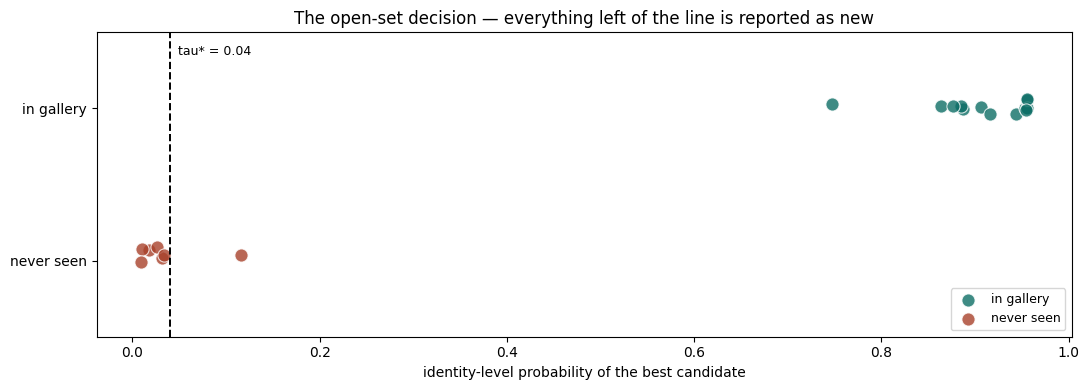

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
jitter = np.random.RandomState(0).normal(0, .04, len(best))
for flag, label, colour in [(True, "in gallery", "#0d6e66"), (False, "never seen", "#a8412a")]:
    m = (best["in_gallery"] == flag).values
    ax.scatter(best.loc[m, "identity_prob"], jitter[m] + flag, s=90, alpha=.8,
               color=colour, label=label, edgecolor="white", linewidth=.8)
ax.axvline(TAU, ls="--", c="k", lw=1.4)
ax.text(TAU, 1.42, f"  tau* = {TAU}", fontsize=9, va="top")
ax.set_yticks([0, 1]); ax.set_yticklabels(["never seen", "in gallery"])
ax.set_xlabel("identity-level probability of the best candidate")
ax.set_title("The open-set decision — everything left of the line is reported as new")
ax.legend(loc="lower right", fontsize=9); ax.set_ylim(-.5, 1.5)
plt.tight_layout(); plt.show()

### Where it went wrong

Every row here is a query the pipeline would have handed to an expert with the
wrong answer at the top. That is what the review checkpoint in `scripts/Q4` is
for: ReMatch ranks candidates, a person confirms them, and only then does
`scripts/Q5-add_results_to_db.py` write anything into the database.

1 of 20 queries wrong:

  C328_IMG_1026.png          expected NEW INDIVIDUAL     got lizard_C56         (p=0.116)


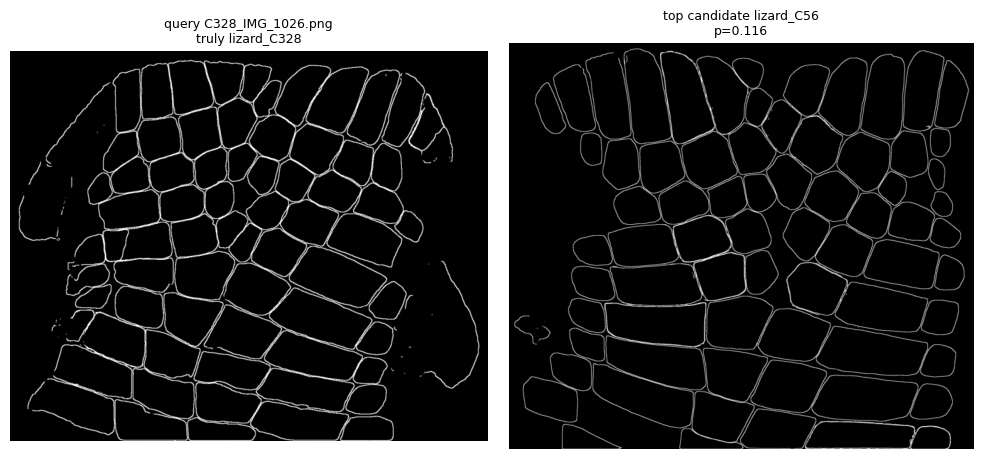

In [7]:
errs = best[(best["in_gallery"] & ((best["id2"] != best["true_identity"]) | (best["identity_prob"] < TAU)))
            | (~best["in_gallery"] & (best["identity_prob"] >= TAU))]

if errs.empty:
    print("No errors on this batch.")
else:
    print(f"{len(errs)} of {len(best)} queries wrong:\n")
    for r in errs.itertuples():
        expected = r.true_identity if r.in_gallery else "NEW INDIVIDUAL"
        print(f"  {r.query:26} expected {expected:18} got {r.prediction:18} (p={r.identity_prob:.3f})")

    show = list(errs.itertuples())[:3]
    fig, axes = plt.subplots(len(show), 2, figsize=(10, 4.5*len(show)), squeeze=False)
    for i, r in enumerate(show):
        axes[i][0].imshow(D.load_gray(QUERY / r.query), cmap="gray")
        axes[i][0].set_title(f"query {r.query}\ntruly {r.true_identity}", fontsize=9)
        cand = D.list_images(PATTERN / r.id2)
        if cand:
            axes[i][1].imshow(D.load_gray(cand[0]), cmap="gray")
            axes[i][1].set_title(f"top candidate {r.id2}\np={r.identity_prob:.3f}", fontsize=9)
        for j in (0, 1): axes[i][j].axis("off")
    plt.tight_layout(); plt.show()

## Next

- **Your own data** — put labelled images in `data/images/<individual>/` and run
  `scripts/P1`–`P4`, then `scripts/Q1`–`Q5` on each new batch. The
  [README](README.md) walks through both, including how to adapt the
  segmentation stage to a different species.
- **The full lizard dataset** — 4 619 photographs of 1 009 individuals, on
  [Kaggle](https://www.kaggle.com/datasets/roberalcaraz/baleariclizard) and
  documented in [*Scientific Data*](https://doi.org/10.1038/s41597-026-07411-z).
- **Growing the gallery** — `scripts/Q5-add_results_to_db.py` merges a reviewed
  batch into the database, so it grows as you work.